#Tasks
(1) Using the dataset provided above
* Use your plot functions to determine if the distributions are well suited for classification tasks!
* Start by implementing your own version of the "Logistic Regression" exercise above.
-->  Please provide the code you used to train your model, the summary of the model, and a plot of your logistic regression model. The following link includes 2 methods to generate this plot:  (https://www.geeksforgeeks.org/how-to-plot-a-logistic-regression-curve-in-r/) Links to an external site.


 (2) Using the same data from part (1),
 * Apply the "Linear Discriminate" method. Include the class predictions for your trained model, then plot the results for the  and compare the results.
-- > Please provide your code, relevant summary/metrics and plots for your model using plot(lda.fit) [as given in the lab] or pairs.lda (MASS).

 (3) Implement and assess a Classification model:
1. Select a dataset and classification TARGET and select the relevant
features you wish to use. [You may use data from ISLR or MASS -- or one of the sets we've worked with so far].
You can either choose a binary classification (where applicable) or a multi-class target using the LDA method.
You may use either a single factor classification (only one feature) or multiple features (I suggest you limit your selection to 5). -- No performance metrics are required in this case, we will assess feature selection in a later assignment.
Select the division scale (test set size) and perform a fit for your model on the training data.
2. Repeat the process from the previous step using the k-fold methods:
Recall selection of k-fold number is important, you may select any valid value for the range we've discussed.  

#Questions
1. Did your performance assessment of the model generated change based on the results of your k-fold analsys?
2. What properties or limitations of your dataset (or selected predictors) do you feel most contributed to shortcomings in model performance (if your models are very low accuracy, be sure to emphasize this response as it may help your score to be able to explain why your efforts didn't generate good* results).
*good results are relative to each dataset, but true classification ratios of <60% are generally considered very limited in their utility.

In [ ]:
install.packages("ISLR2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
#Import WDBC Data
#(1) Use the dataset provided above
source_file_url = "https://raw.githubusercontent.com/joelvinas/COMP-SCI_5565/refs/heads/main/Assignment%203/Data/wdbc.data"

wdbc_data <- read.csv(source_file_url)
all_headers <- c("ID", "Diagnosis",
                 "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1",
                 "radius2", "texture2", "perimeter2", "area2", "smoothness2", "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2",
                 "radius3", "texture3", "perimeter3", "area3", "smoothness3", "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3")

colnames(wdbc_data) <- all_headers
#wdbc_data$Diagnosis[wdbc_data$Diagnosis == "M"] <- 1   #M for Malignant
#wdbc_data$Diagnosis[wdbc_data$Diagnosis == "B"] <- 0  #B for Benign

# Gemini Code suggestion: Robustly convert Diagnosis to numeric 0/1 (0 for 'B', 1 for 'M')
wdbc_data$Diagnosis <- as.numeric(wdbc_data$Diagnosis == "M")

#Break the dataset into 5 parts for later 5-Fold analysis
num_parts <- 5
wdbc_data$DataGroup <- rep(1:num_parts, length.out = nrow(wdbc_data))

head(wdbc_data)

#Split the dataset into the 3 dimensions
wdbc_data1 <- wdbc_data[, c(1,2, 3:12, 33)]
wdbc_data2 <- wdbc_data[, c(1,2, 13:22, 33)]
wdbc_data3 <- wdbc_data[, c(1,2, 23:32, 33)]

# Define new headers for subset
part_headers <- c("ID", "Diagnosis", "radius", "texture", "perimeter", "area", "smoothness", "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension", "data_group")

# Assign the new headers to the new data frames
colnames(wdbc_data1) <- part_headers
colnames(wdbc_data2) <- part_headers
colnames(wdbc_data3) <- part_headers

head(wdbc_data1)
head(wdbc_data2)
head(wdbc_data3)

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,⋯,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,DataGroup
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,⋯,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,⋯,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,2
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,⋯,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,3
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,⋯,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,4
5,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,⋯,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,5
6,844359,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.1127,0.07400,⋯,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,1


,ID,Diagnosis,radius,texture,perimeter,area,smoothness,compactness,concavity,concave_points,symmetry,fractal_dimension,data_group
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,1
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,2
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,3
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,4
5,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,5
6,844359,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.1127,0.07400,0.1794,0.05742,1


,ID,Diagnosis,radius,texture,perimeter,area,smoothness,compactness,concavity,concave_points,symmetry,fractal_dimension,data_group
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,842517,1,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,1
2,84300903,1,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,2
3,84348301,1,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,3
4,84358402,1,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,4
5,843786,1,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082,5
6,844359,1,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,1


,ID,Diagnosis,radius,texture,perimeter,area,smoothness,compactness,concavity,concave_points,symmetry,fractal_dimension,data_group
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,842517,1,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,1,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,2
3,84348301,1,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,3
4,84358402,1,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,4
5,843786,1,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,5
6,844359,1,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,1


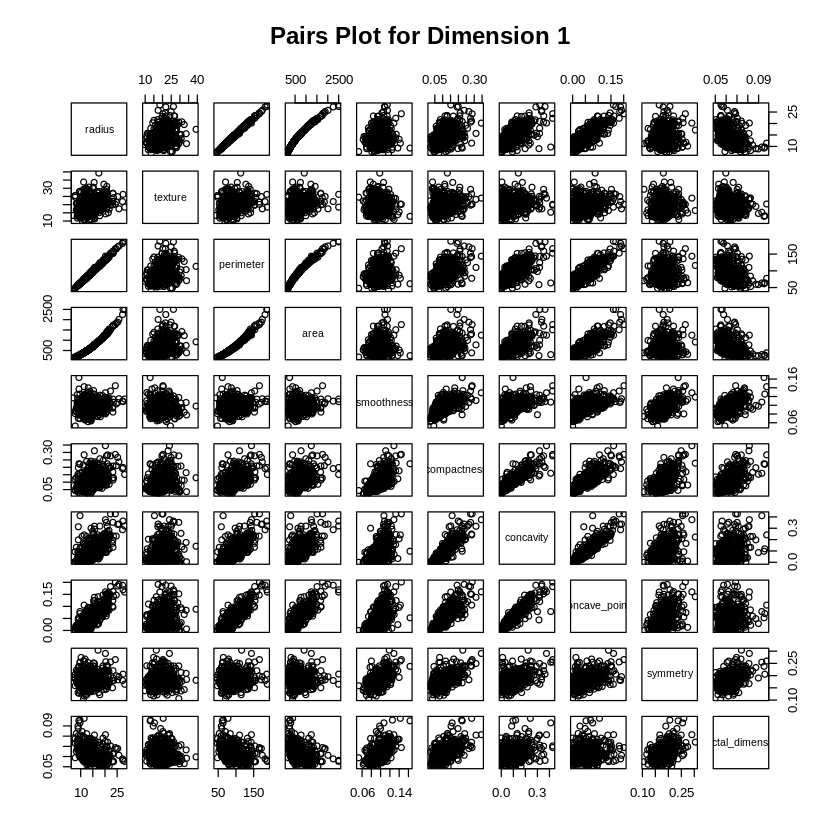

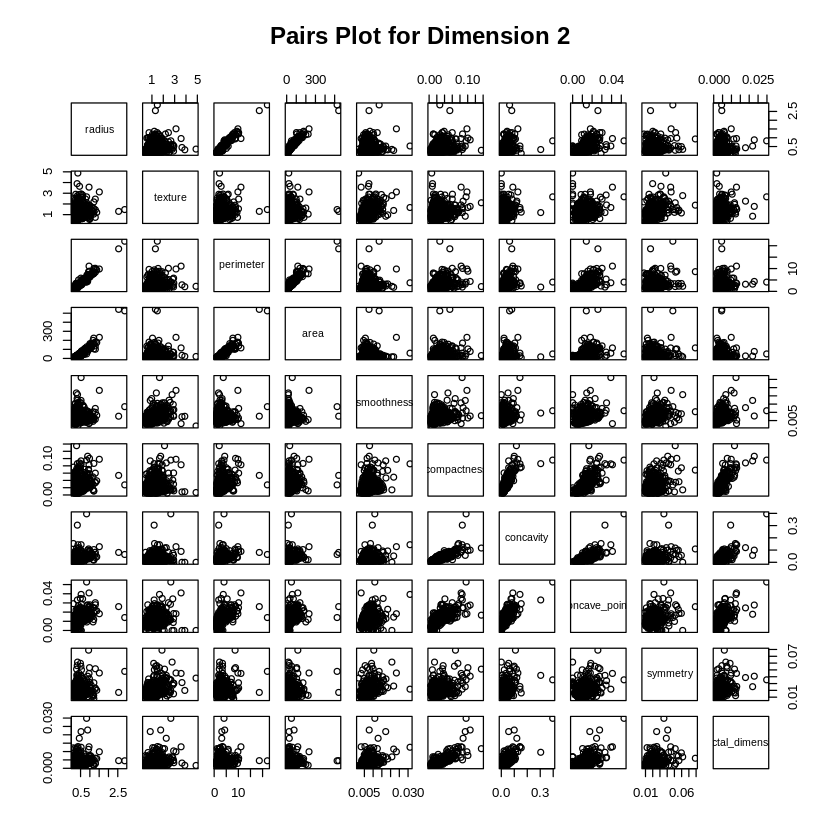

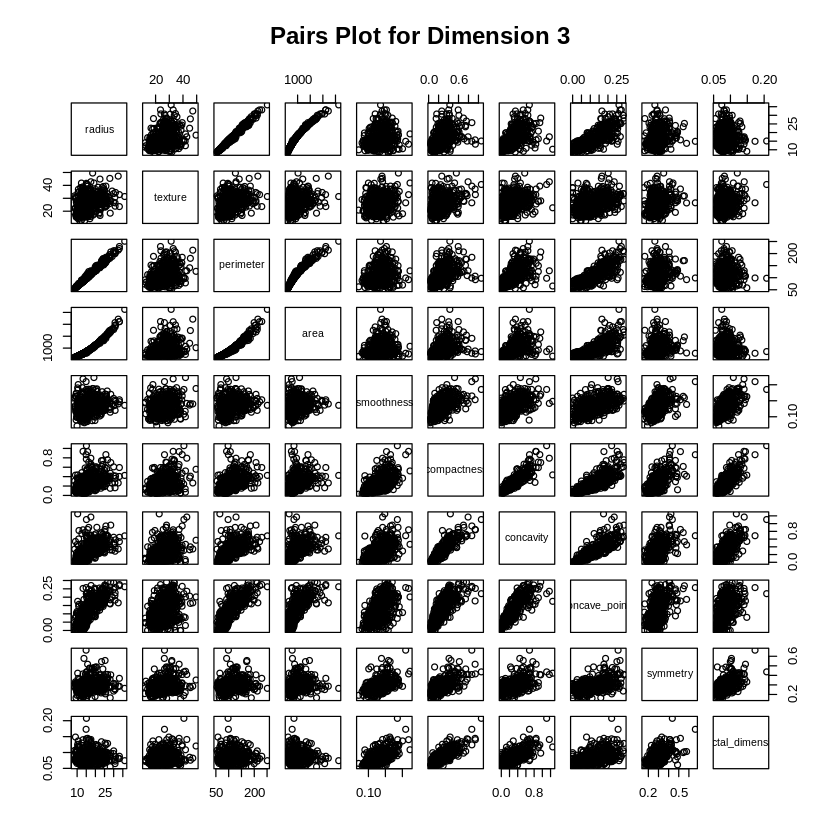

In [3]:
#Use plot functions to determine if the distributions are well suited for classification tasks
# Set par(mfrow = c(1,1)) to display each plot individually for larger size
par(mfrow = c(1,1))
pairs(wdbc_data1[, -c(1:2,13)], main = 'Pairs Plot for Dimension 1')
pairs(wdbc_data2[, -c(1:2,13)], main = 'Pairs Plot for Dimension 2')
pairs(wdbc_data3[, -c(1:2,13)], main = 'Pairs Plot for Dimension 3')
par(mfrow = c(1,1)) # Reset plot layout after the last plot

In [6]:
#Start by implementing your own version of the "Logistic Regression" exercise above. -->
#Please provide the code you used to train your model, the summary of the model, and a plot of your logistic regression model.
#The following link includes 2 methods to generate this plot: (https://www.geeksforgeeks.org/how-to-plot-a-logistic-regression-curve-in-r/) Links to an external site.
#logistic_model1 <- glm(var1 ~ var2, data=wdbc_data1, family=binomial)
#predicted_data <- data.frame(var2=seq(min(), max(), len=500))

dataframe_list <- list("Dim 1" = wdbc_data1, "Dim 2" = wdbc_data2, "Dim 3" = wdbc_data3)

for (df_name in names(dataframe_list)) {
  current_df <- dataframe_list[[df_name]]

  glm.fits <- suppressWarnings(
    glm(Diagnosis ~ radius + texture + perimeter + area + smoothness + compactness + concavity + concave_points + symmetry + fractal_dimension,
      data = current_df,
      family = binomial)
    )
  print(paste("====", df_name, "===="))
  print(summary(glm.fits))
}

[1] "==== Dim 1 ===="

Call:
glm(formula = Diagnosis ~ radius + texture + perimeter + area + 
    smoothness + compactness + concavity + concave_points + symmetry + 
    fractal_dimension, family = binomial, data = current_df)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -7.35983   12.85270  -0.573   0.5669    
radius             -2.04923    3.71590  -0.551   0.5813    
texture             0.38473    0.06454   5.961  2.5e-09 ***
perimeter          -0.07151    0.50516  -0.142   0.8874    
area                0.03980    0.01674   2.377   0.0174 *  
smoothness         76.43231   31.95490   2.392   0.0168 *  
compactness        -1.46251   20.34247  -0.072   0.9427    
concavity           8.46881    8.12006   1.043   0.2970    
concave_points     66.82118   28.52923   2.342   0.0192 *  
symmetry           16.27816   10.63058   1.531   0.1257    
fractal_dimension -68.33655   85.55655  -0.799   0.4244    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’

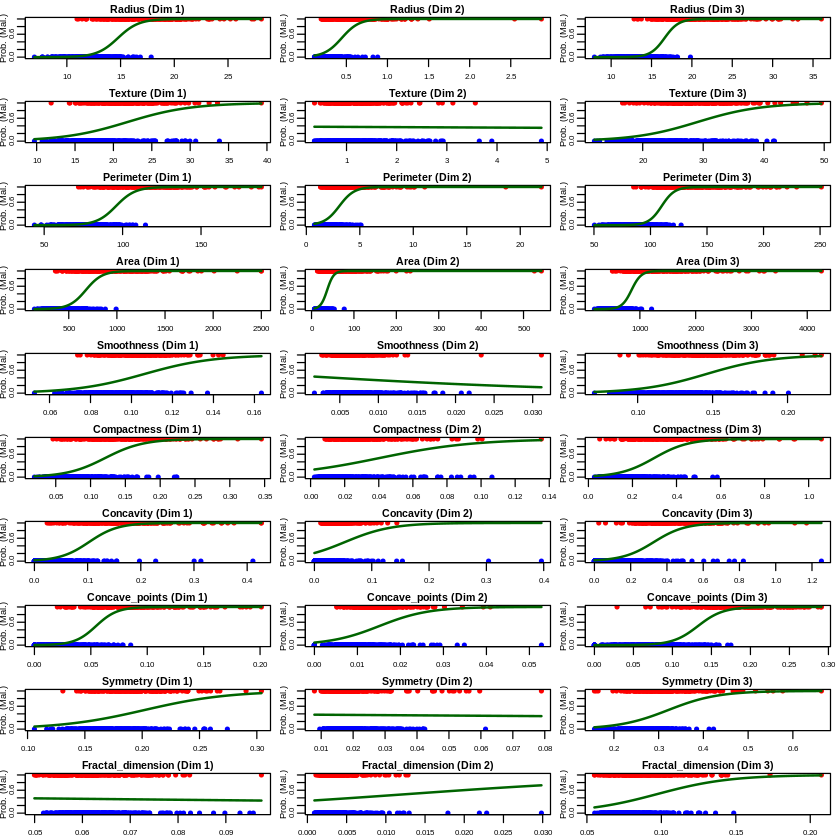

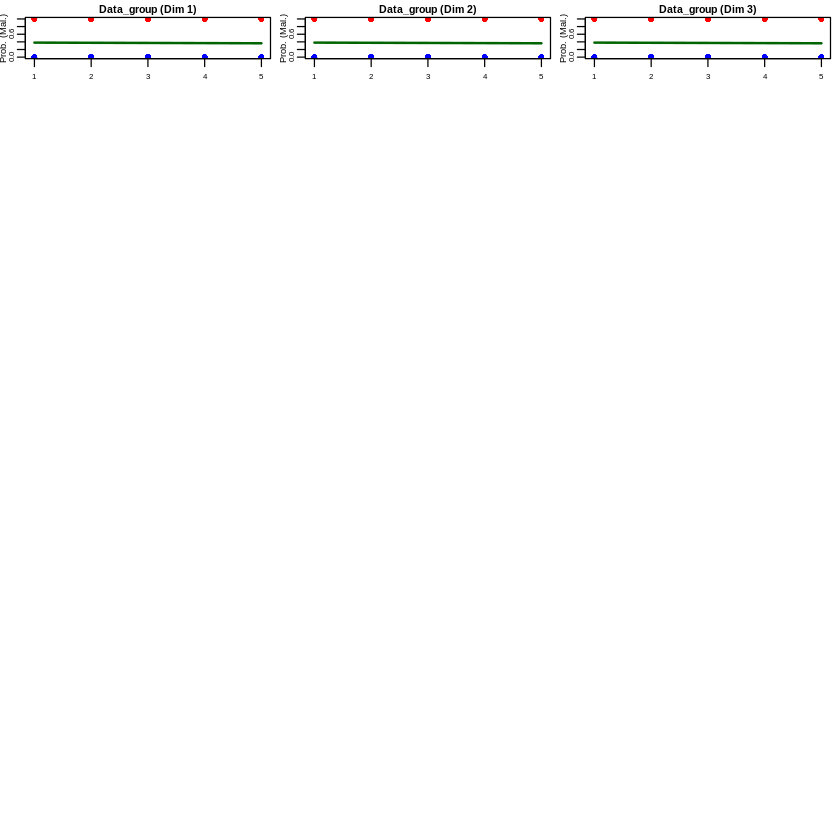

In [ ]:
#!! The below code was produced with assistance from Google Gemini !!
#!! Prompt and response can be found within the AI_Prompts directory

#==Generalized Logistic Regression Plotting Function==
#This code block introduces a plot_logistic_regression function that takes a predictor variable name as an argument.
#This allows logistic regression plots for different features without rewriting the code each time.

plot_logistic_regression <- function(predictor_name, data_frame, data_name) {
  # Create logistic regression model using the specified predictor
  formula_str <- paste0("Diagnosis ~ ", predictor_name)
  logistic_model <- suppressWarnings(glm(
    as.formula(formula_str),
    data = data_frame,
    family = binomial
  ))

  # Get the range for the chosen predictor
  predictor_range <- seq(min(data_frame[[predictor_name]]), max(data_frame[[predictor_name]]), len = 500)

  # Calculate the means of all predictor variables in data_frame (excluding 'ID' and 'Diagnosis')
  predictor_means <- colMeans(data_frame[, !(names(data_frame) %in% c("ID", "Diagnosis"))])

  # Create a data frame for predictions with the specified predictor varying and others at their means
  Predicted_data <- data.frame(matrix(ncol = length(names(predictor_means)), nrow = 500))
  colnames(Predicted_data) <- names(predictor_means)

  Predicted_data[[predictor_name]] <- predictor_range
  for (col_name in names(predictor_means)) {
    if (col_name != predictor_name) { # Set other predictors to their mean
      Predicted_data[[col_name]] <- predictor_means[col_name]
    }
  }

  # Fill predicted values using regression model
  Predicted_data$prob <- predict(logistic_model, Predicted_data, type = "response")

  # Plot Predicted data and original data points
  # Shorten plot title and y-axis label, and reduce font sizes for better fitting in multi-plot layout
  plot_title <- paste0(tools::toTitleCase(predictor_name), " (", data_name, ")")
  # xlab = tools::toTitleCase(predictor_name) - Replaced with null to make more visible
  plot(data_frame[[predictor_name]], data_frame$Diagnosis,
       xlab = "", ylab = "Prob. (Mal.)",
       main = plot_title,
       pch = 20, col = ifelse(data_frame$Diagnosis == 1, "red", "blue"),
       cex.axis = 0.6, cex.lab = 0.7, cex.main = 0.8
       ) # Differentiate points by Diagnosis
  lines(Predicted_data[[predictor_name]], Predicted_data$prob, col = "darkgreen", lwd = 2)
}

# Set global plot layout and significantly smaller margins/text sizes for all plots
par(mfrow = c(10, 3), mar = c(1.5, 1.5, 1, 0.5) + 0.1, oma = c(0, 0, 0, 0), mgp = c(1, 0.5, 0))

dataframe_list <- list("Dim 1" = wdbc_data1, "Dim 2" = wdbc_data2, "Dim 3" = wdbc_data3)

# Get the list of all predictor variables (excluding ID and Diagnosis)
predictor_vars <- names(wdbc_data1)[!(names(wdbc_data1) %in% c("ID", "Diagnosis"))]

for (pred_var in predictor_vars) {

  # Loop through each predictor and generate a plot for the current dataframe
  for (df_name in names(dataframe_list)) {
    current_df <- dataframe_list[[df_name]]
    plot_logistic_regression(pred_var, current_df, df_name)
  }
}
# Reset plot layout and margins to default after all plots are generated
par(mfrow = c(1,1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0), mgp = c(3, 1, 0))

In [ ]:
dataframe_list <- list("Dim 1" = wdbc_data1, "Dim 2" = wdbc_data2, "Dim 3" = wdbc_data3)

for (df_name in names(dataframe_list)) {
  current_df <- dataframe_list[[df_name]]

  glm.fits <- suppressWarnings(
  glm(Diagnosis ~ radius + texture + perimeter + area + smoothness + compactness + concavity + concave_points + symmetry + fractal_dimension,
    data = current_df,
    family = binomial)
  )
  print(paste("===",df_name,"==="))
  #summary(glm.fits)

  #print(coef(glm.fits))

  print(summary(glm.fits)$coef)

  glm.probs <- predict(glm.fits, type = "response")
  print(glm.probs[1:10])

  # Adjust length of glm.pred to match the number of rows in the dataset (569)
  glm.pred <- rep(0, nrow(current_df))
  glm.pred[glm.probs > .5] = 1
  print(table(glm.pred, current_df$Diagnosis))

  glm.probs <- predict(glm.fits, type = "response")
  print(glm.probs[1:10])

  print(paste(df_name, mean(glm.pred == current_df$Diagnosis)))
}


#summary(glm.fits)$coef[, 4]



[1] "=== Dim 1 ==="
                      Estimate  Std. Error    z value     Pr(>|z|)
(Intercept)        -7.35983192 12.85269862 -0.5726293 5.668957e-01
radius             -2.04922616  3.71589697 -0.5514755 5.813078e-01
texture             0.38473361  0.06453673  5.9614675 2.499827e-09
perimeter          -0.07151462  0.50516434 -0.1415670 8.874220e-01
area                0.03979558  0.01673994  2.3772831 1.744070e-02
smoothness         76.43230828 31.95489615  2.3918810 1.676228e-02
compactness        -1.46251366 20.34246884 -0.0718946 9.426858e-01
concavity           8.46881174  8.12005583  1.0429499 2.969715e-01
concave_points     66.82118162 28.52922646  2.3422010 1.917039e-02
symmetry           16.27815806 10.63058179  1.5312575 1.257058e-01
fractal_dimension -68.33654956 85.55654560 -0.7987296 4.244472e-01
        1         2         3         4         5         6         7         8 
0.9999894 0.9999999 0.9822755 0.9999987 0.6692695 0.9995616 0.7736619 0.9923905 
        9     

In [ ]:
library(dplyr)
#set.seed(2148)

dataframe_list <- list("Dim 1" = wdbc_data1, "Dim 2" = wdbc_data2, "Dim 3" = wdbc_data3)

for (df_name in names(dataframe_list)) {
  current_df <- dataframe_list[[df_name]]

  for (cur_group in 1:5) {
  trainData <- current_df %>%
    filter(data_group != cur_group)
  testData <- current_df %>%
    filter(data_group == cur_group)

  glm.fits <- suppressWarnings(
    glm(Diagnosis ~ radius + texture + perimeter + area + smoothness + compactness + concavity + concave_points + symmetry + fractal_dimension,
      data = trainData,
      family = binomial)
    )

  glm.probs <- predict(glm.fits, testData, type = "response")

  totalRows <- nrow(testData)

  glm.pred <- rep(0, totalRows)
  glm.pred[glm.probs > 0.5] <- 1

  print(paste(df_name,": ", cur_group))
  print(table(glm.pred, testData$Diagnosis))
  print(paste("Train:",mean(glm.pred != testData)))
  print(paste("Test: ",mean(glm.pred == testData)))
  }
}

[1] "Dim 1 :  1"
        
glm.pred  0  1
       0 74  5
       1  2 33
[1] "Train: 0.900134952766532"
[1] "Test:  0.0998650472334683"
[1] "Dim 1 :  2"
        
glm.pred  0  1
       0 60  1
       1  4 49
[1] "Train: 0.923751686909582"
[1] "Test:  0.0762483130904184"
[1] "Dim 1 :  3"
        
glm.pred  0  1
       0 67  2
       1  5 40
[1] "Train: 0.923751686909582"
[1] "Test:  0.0762483130904184"
[1] "Dim 1 :  4"
        
glm.pred  0  1
       0 70  7
       1  1 35
[1] "Train: 0.925799863852961"
[1] "Test:  0.0742001361470388"
[1] "Dim 1 :  5"
        
glm.pred  0  1
       0 71  5
       1  3 34
[1] "Train: 0.924438393464942"
[1] "Test:  0.0755616065350579"
[1] "Dim 2 :  1"
        
glm.pred  0  1
       0 71  9
       1  5 29
[1] "Train: 0.904858299595142"
[1] "Test:  0.0951417004048583"
[1] "Dim 2 :  2"
        
glm.pred  0  1
       0 62  4
       1  2 46
[1] "Train: 0.92442645074224"
[1] "Test:  0.0755735492577598"
[1] "Dim 2 :  3"
        
glm.pred  0  1
       0 63  7
       

In [ ]:
#2) Using the same data from part (1), apply the "Linear Discriminate" method.
#Include the class predictions for your trained model,
#then plot the results for the  and compare the results.
#-- > Please provide your code, relevant summary/metrics and plots for your model using plot(lda.fit)
#[as given in the lab] #or pairs.lda (MASS).

[1] "Dim 1 , Fold 1"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6189427 0.3810573 

Group means:
    radius  texture perimeter     area smoothness compactness  concavity
0 12.19325 17.97370  78.34915 465.7954 0.09203822  0.07879907 0.04519454
1 17.52393 21.63283 115.81780 983.1642 0.10342665  0.14722179 0.16444647
  concave_points  symmetry fractal_dimension
0     0.02569891 0.1736413        0.06257751
1     0.08926792 0.1933636        0.06287335

Coefficients of linear discriminants:
                           LD1
radius             2.597045485
texture            0.095242575
perimeter         -0.300362618
area              -0.004566093
smoothness         3.070983307
compactness        4.510874526
concavity          2.253055314
concave_points    28.780202724
symmetry           3.951213525
fractal_dimens

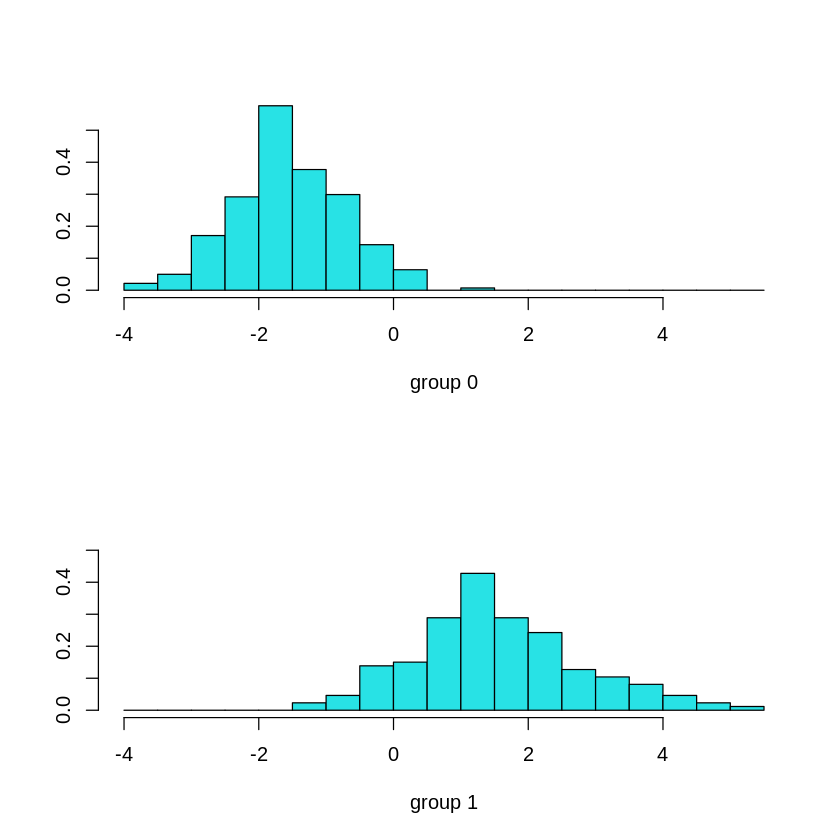

[1] ""
[1] "Dim 1 , Fold 3"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6277533 0.3722467 

Group means:
    radius  texture perimeter     area smoothness compactness  concavity
0 12.11180 17.89484  77.84151 459.7621 0.09276639  0.08000025 0.04493389
1 17.40799 21.59420 114.88006 973.2189 0.10221544  0.14214929 0.15706112
  concave_points  symmetry fractal_dimension
0     0.02520501 0.1739881        0.06299042
1     0.08628982 0.1924189        0.06225663

Coefficients of linear discriminants:
                           LD1
radius             1.912778172
texture            0.092384903
perimeter         -0.187988909
area              -0.005374465
smoothness        11.925996074
compactness       -1.612395937
concavity          3.913535297
concave_points    28.298999170
symmetry           4.840228278
fractal

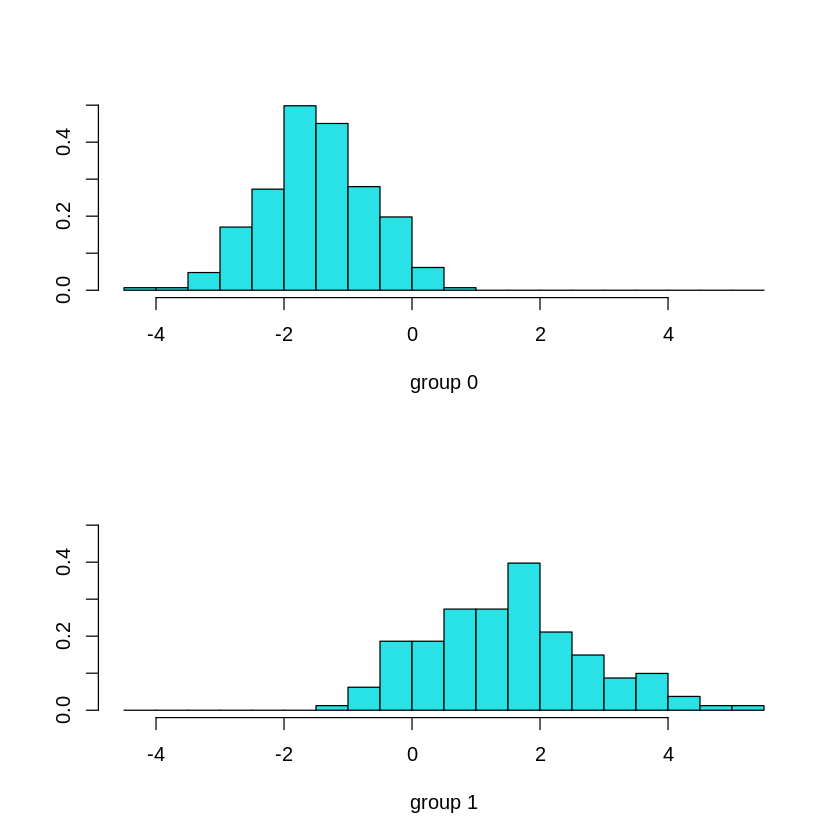

[1] ""
[1] "Dim 1 , Fold 4"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6285714 0.3714286 

Group means:
    radius  texture perimeter     area smoothness compactness  concavity
0 12.17896 18.08287  78.32829 465.6087 0.09227311  0.08095385 0.04748596
1 17.59503 21.46207 116.34929 993.7414 0.10340414  0.14718006 0.16389527
  concave_points  symmetry fractal_dimension
0     0.02615919 0.1742797        0.06305741
1     0.09005396 0.1942982        0.06277408

Coefficients of linear discriminants:
                           LD1
radius             2.041772399
texture            0.089869260
perimeter         -0.233754582
area              -0.003785609
smoothness         9.935209710
compactness       -1.265734038
concavity          3.284103189
concave_points    31.521577933
symmetry           5.087563569
fractal

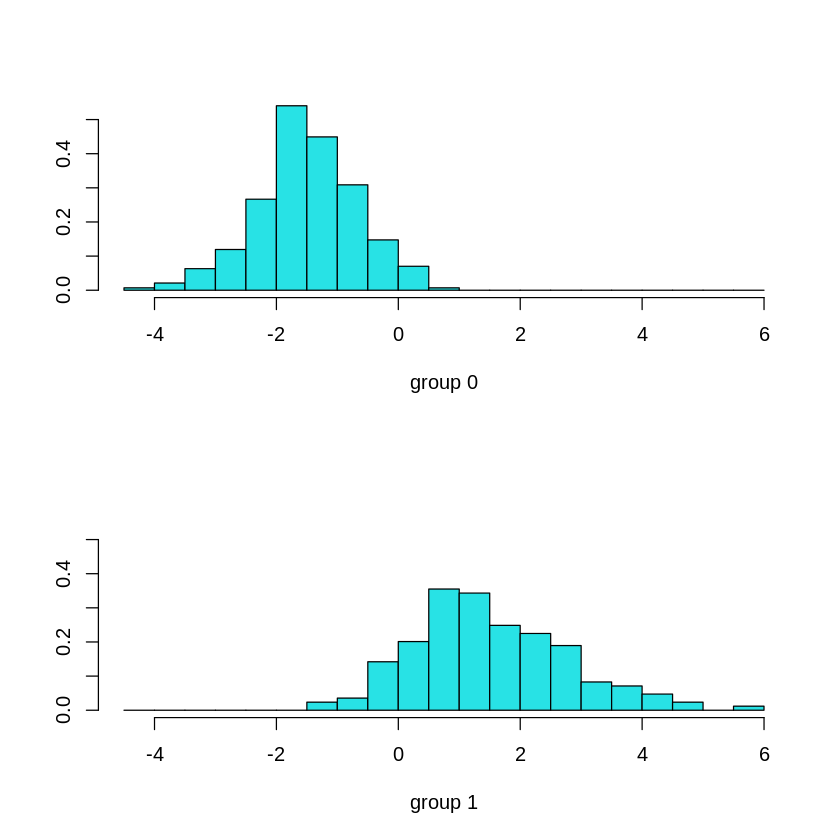

[1] ""
[1] "Dim 1 , Fold 5"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
       0        1 
0.621978 0.378022 

Group means:
    radius  texture perimeter     area smoothness compactness  concavity
0 12.15726 17.89700  78.12527 464.0032 0.09181318  0.07960922 0.04702219
1 17.53959 21.64669 115.90215 986.8640 0.10289727  0.14586866 0.16152390
  concave_points  symmetry fractal_dimension
0     0.02539394 0.1737240        0.06271396
1     0.08842291 0.1927599        0.06275488

Coefficients of linear discriminants:
                           LD1
radius             2.157369751
texture            0.106137315
perimeter         -0.247515922
area              -0.003822039
smoothness         7.257116395
compactness        0.272941483
concavity          0.656687048
concave_points    33.959111528
symmetry           4.881190803
fractal_dim

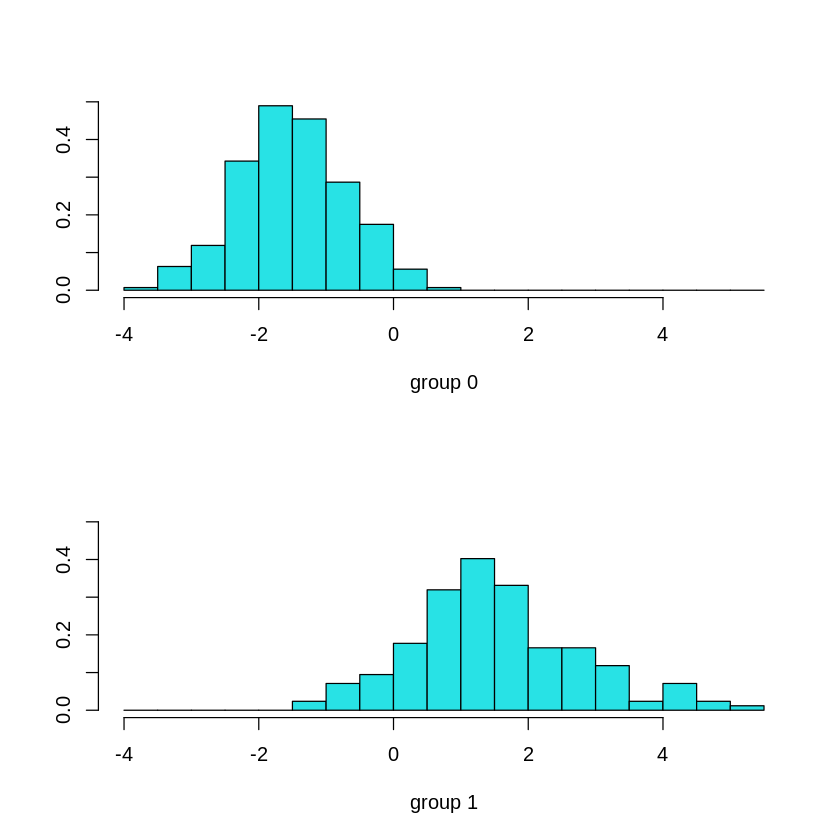

[1] ""
[1] "Dim 2 , Fold 1"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6189427 0.3810573 

Group means:
     radius  texture perimeter     area  smoothness compactness  concavity
0 0.2831609 1.215372  1.978805 21.20858 0.007135445  0.02072301 0.02560171
1 0.6112081 1.218365  4.336983 72.17133 0.006775543  0.03302651 0.04255353
  concave_points   symmetry fractal_dimension
0    0.009805224 0.02064480       0.003544186
1    0.015118191 0.02045768       0.004165740

Coefficients of linear discriminants:
                            LD1
radius             4.953002e+00
texture           -1.685835e-01
perimeter         -3.950889e-01
area               9.060762e-03
smoothness        -9.244943e+01
compactness        4.493515e+01
concavity         -7.766247e+00
concave_points     8.386156e+01
symmetry          -2

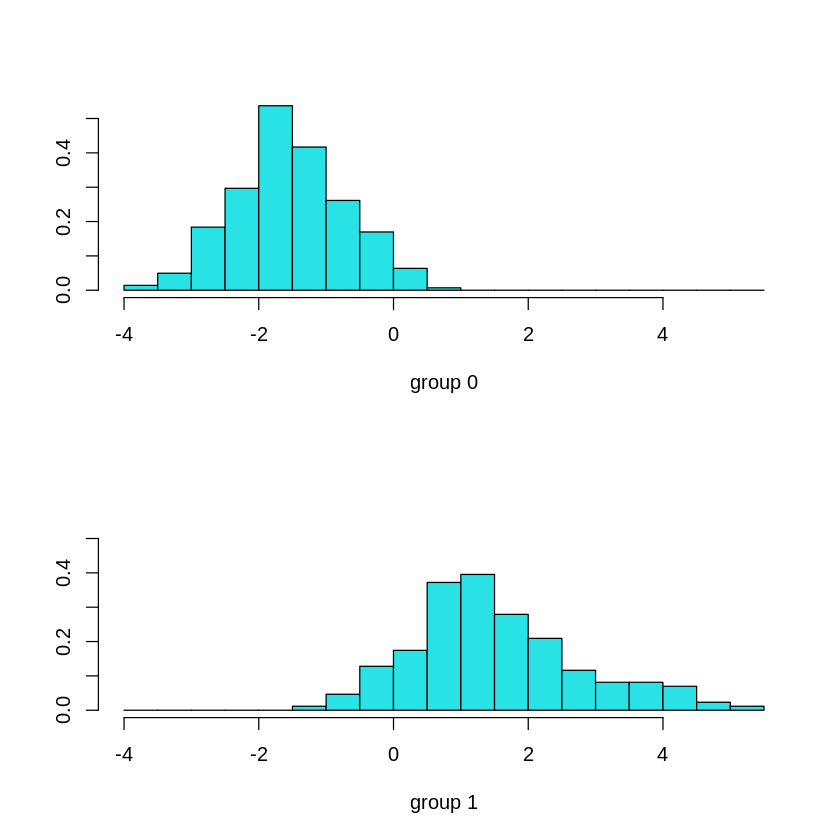

[1] ""
[1] "Dim 2 , Fold 2"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6453744 0.3546256 

Group means:
     radius  texture perimeter     area  smoothness compactness  concavity
0 0.2883846 1.210295  2.024768 21.36382 0.007394928  0.02156427 0.02532022
1 0.5780478 1.194504  4.079646 67.99422 0.006707366  0.03031973 0.03990839
  concave_points   symmetry fractal_dimension
0    0.009910369 0.02070372       0.003602237
1    0.014619826 0.02003440       0.003845677

Coefficients of linear discriminants:
                            LD1
radius             5.478823e+00
texture           -1.468260e-01
perimeter         -2.340919e-01
area              -2.107893e-05
smoothness        -9.058469e+01
compactness        4.003405e+01
concavity          8.239519e-01
concave_points     4.343702e+01
symmetry          -2

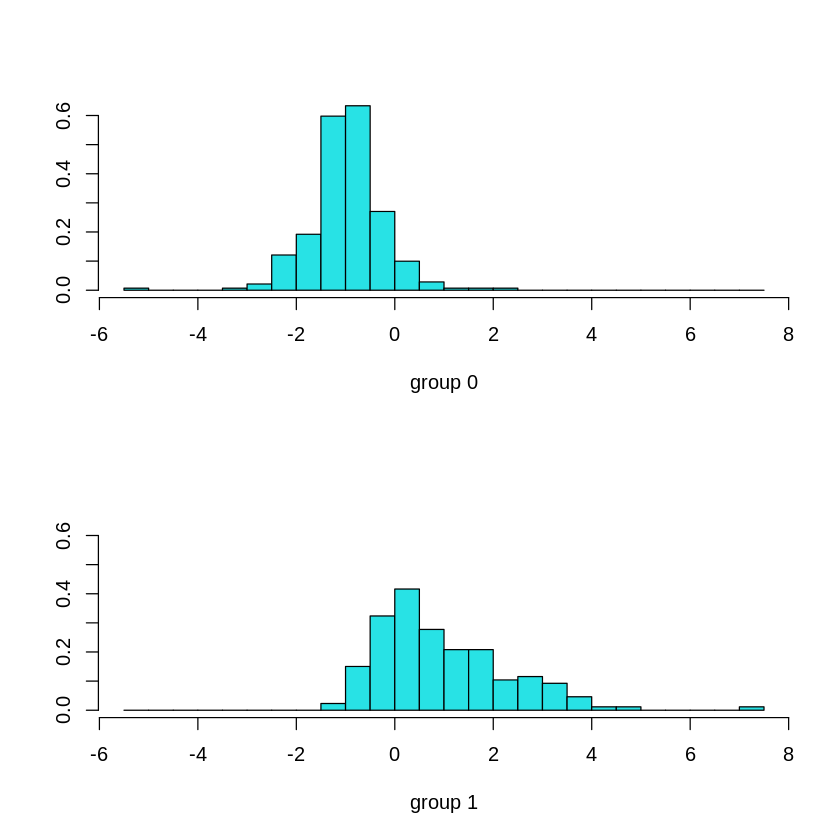

[1] ""
[1] "Dim 2 , Fold 3"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6277533 0.3722467 

Group means:
     radius  texture perimeter     area  smoothness compactness  concavity
0 0.2845723 1.211872  2.015969 21.09813 0.007220996  0.02152367 0.02542882
1 0.5881201 1.188238  4.163183 70.54343 0.006673124  0.03143983 0.04122503
  concave_points   symmetry fractal_dimension
0    0.009705551 0.02060368       0.003645133
1    0.014761290 0.02002442       0.003972811

Coefficients of linear discriminants:
                            LD1
radius             8.793975e+00
texture           -1.259679e-01
perimeter         -6.335396e-01
area              -7.871333e-03
smoothness        -9.899408e+01
compactness        4.824941e+01
concavity         -4.142997e-01
concave_points     9.869671e+01
symmetry          -3

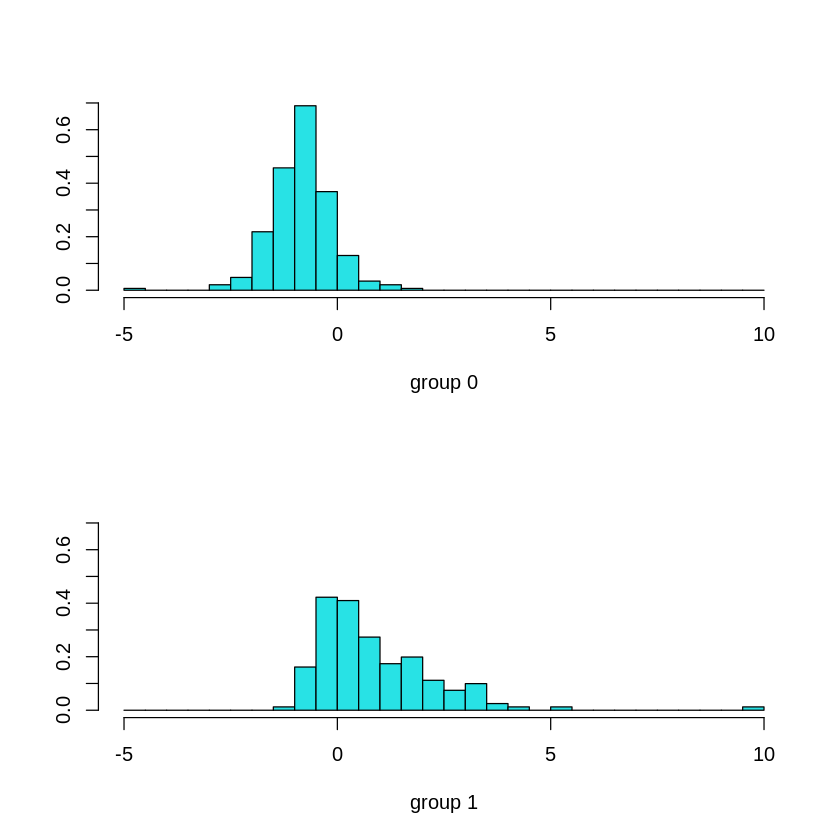

[1] ""
[1] "Dim 2 , Fold 4"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6285714 0.3714286 

Group means:
     radius  texture perimeter     area  smoothness compactness  concavity
0 0.2838769 1.241231  2.006842 21.19945 0.007157626  0.02204000 0.02689200
1 0.6391645 1.234050  4.536550 76.77533 0.006853426  0.03323334 0.04295432
  concave_points   symmetry fractal_dimension
0     0.01003435 0.02075000       0.003781966
1     0.01545141 0.02093983       0.004141160

Coefficients of linear discriminants:
                            LD1
radius               7.64442424
texture             -0.20725233
perimeter           -0.40667219
area                -0.00875696
smoothness         -83.64640719
compactness         43.38344959
concavity           -4.79779250
concave_points      73.73023491
symmetry           -

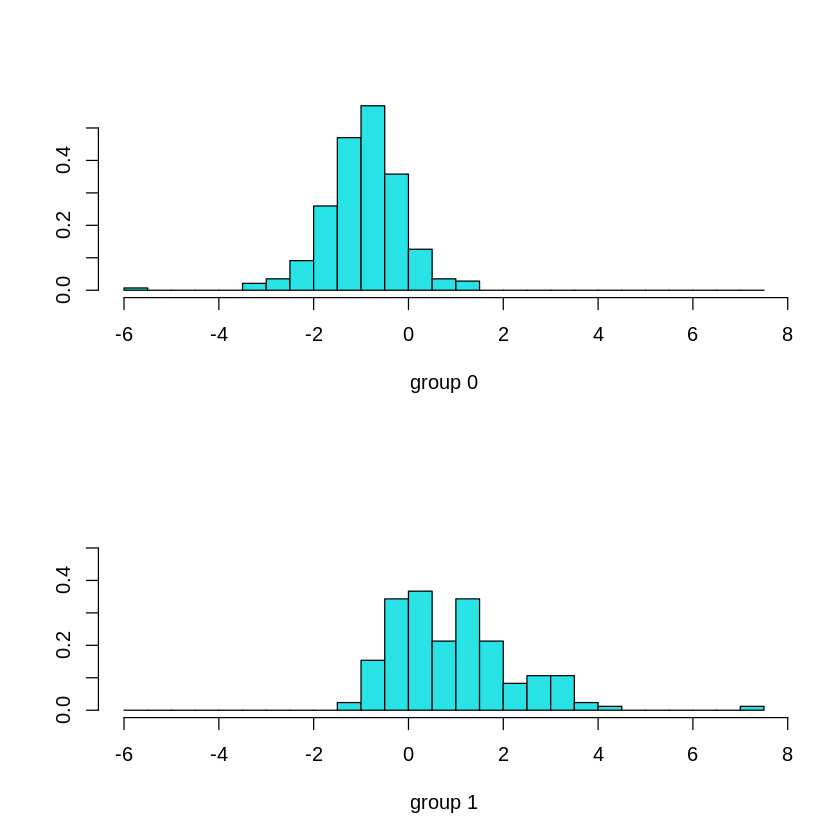

[1] ""
[1] "Dim 2 , Fold 5"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
       0        1 
0.621978 0.378022 

Group means:
     radius  texture perimeter     area  smoothness compactness  concavity
0 0.2802572 1.223290  1.974028 20.79779 0.007063283  0.02132380 0.02675657
1 0.6157337 1.225439  4.389302 73.73849 0.006894663  0.03286883 0.04208442
  concave_points   symmetry fractal_dimension
0    0.009829735 0.02021113       0.003605669
1    0.015305901 0.02065581       0.004122442

Coefficients of linear discriminants:
                            LD1
radius             6.879959e+00
texture           -1.372559e-01
perimeter         -4.446095e-01
area              -3.563124e-03
smoothness        -9.952935e+01
compactness        4.346440e+01
concavity         -9.472997e+00
concave_points     9.167448e+01
symmetry          -2.470

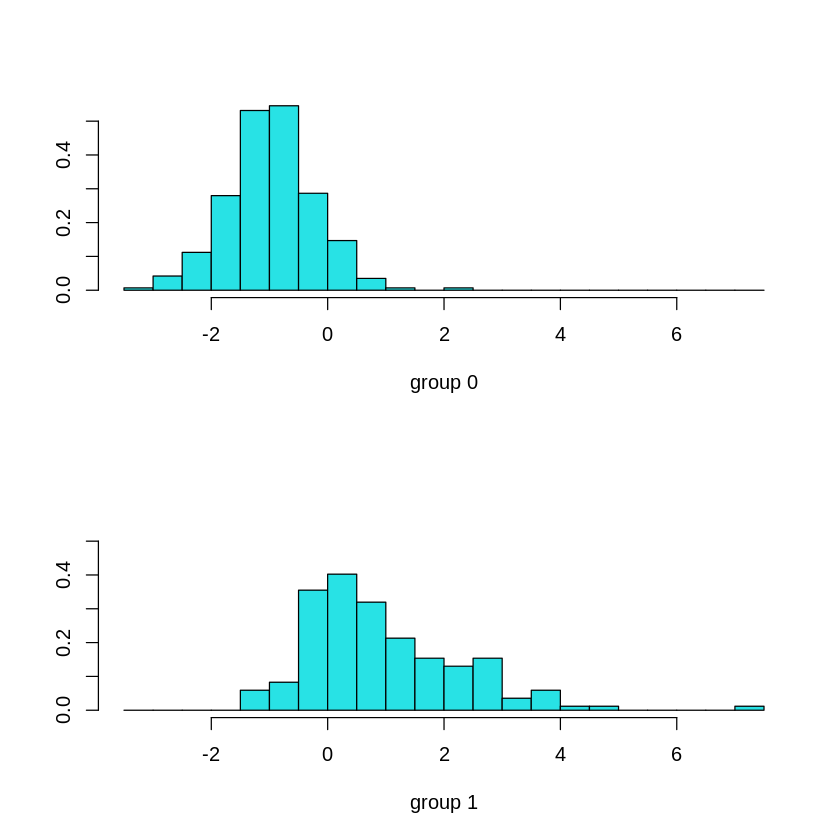

[1] ""
[1] "Dim 3 , Fold 1"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6189427 0.3810573 

Group means:
    radius  texture perimeter      area smoothness compactness concavity
0 13.43548 23.57096  87.31046  562.9587  0.1245616   0.1788892 0.1636143
1 21.19410 29.32902 141.72809 1424.3133  0.1453456   0.3816423 0.4583086
  concave_points  symmetry fractal_dimension
0     0.07469018 0.2705260        0.07899125
1     0.18339688 0.3241659        0.09234364

Coefficients of linear discriminants:
                           LD1
radius             0.700384451
texture            0.050886020
perimeter         -0.016376825
area              -0.002938251
smoothness         7.495364184
compactness       -1.648481850
concavity          0.588017675
concave_points     8.676006047
symmetry           2.437341984
fractal

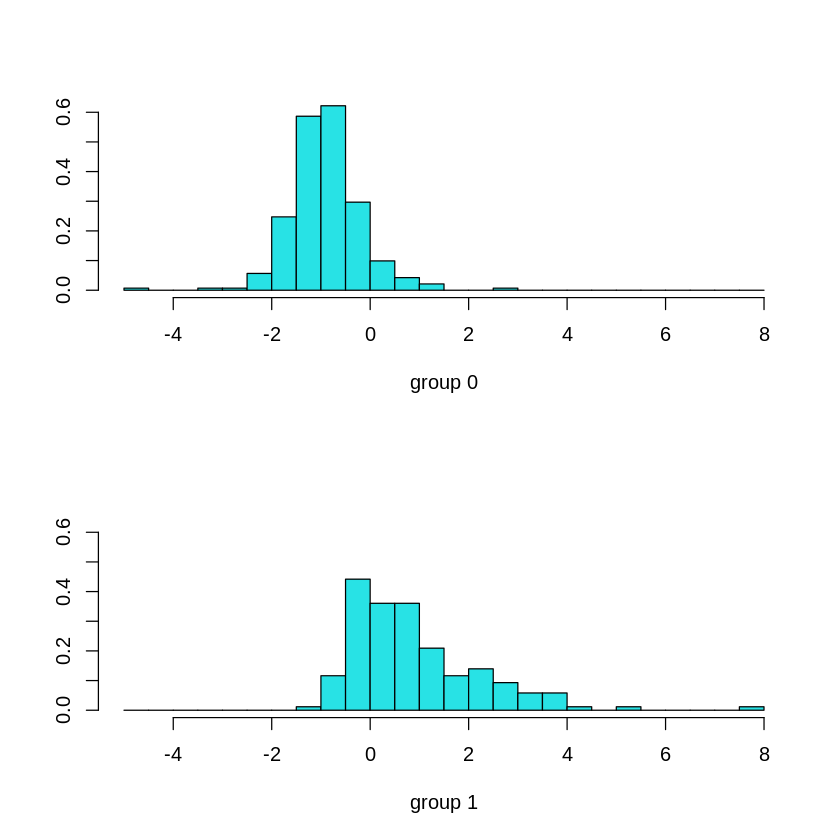

[1] ""
[1] "Dim 3 , Fold 2"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6453744 0.3546256 

Group means:
    radius  texture perimeter      area smoothness compactness concavity
0 13.32736 23.26580  86.61116  554.5266  0.1263383   0.1829296 0.1633274
1 20.86863 29.87435 139.40752 1394.6298  0.1452539   0.3654576 0.4389750
  concave_points  symmetry fractal_dimension
0     0.07392488 0.2704737        0.07939369
1     0.17882609 0.3230578        0.09076677

Coefficients of linear discriminants:
                           LD1
radius             0.573449427
texture            0.059005755
perimeter          0.001227693
area              -0.002903105
smoothness        10.729389896
compactness       -3.037577462
concavity          1.839982303
concave_points     6.612873163
symmetry           2.987065598
fractal

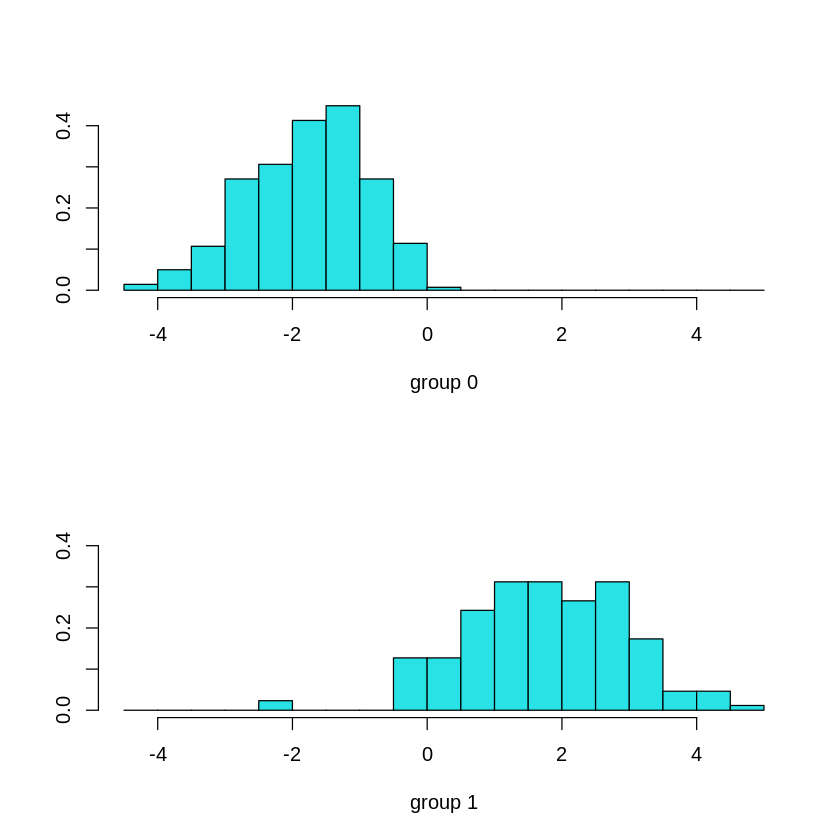

[1] ""
[1] "Dim 3 , Fold 3"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6277533 0.3722467 

Group means:
    radius  texture perimeter      area smoothness compactness concavity
0 13.34758 23.47751  86.83688  555.6133  0.1254921   0.1831679 0.1637454
1 20.98680 29.32633 140.09822 1403.4432  0.1444776   0.3701864 0.4511876
  concave_points  symmetry fractal_dimension
0     0.07387481 0.2695954        0.07943530
1     0.18127006 0.3220923        0.09127929

Coefficients of linear discriminants:
                            LD1
radius             0.5539583401
texture            0.0534507003
perimeter          0.0008032184
area              -0.0028080165
smoothness        11.4725960123
compactness       -3.2615140686
concavity          1.7106008284
concave_points     8.7675845494
symmetry           4.38367406

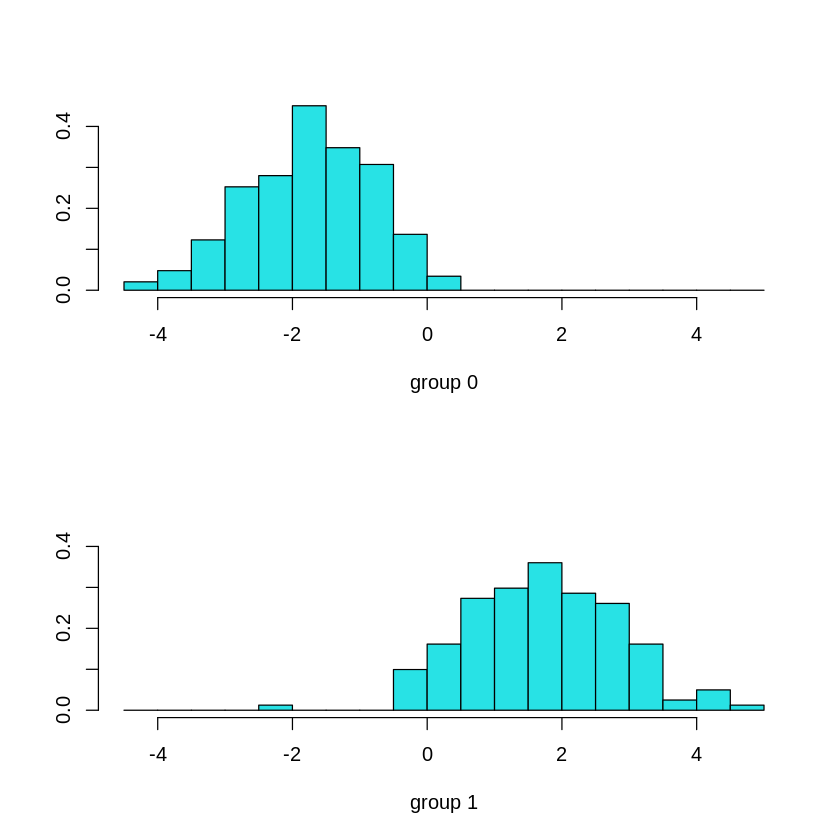

[1] ""
[1] "Dim 3 , Fold 4"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
        0         1 
0.6285714 0.3714286 

Group means:
    radius  texture perimeter     area smoothness compactness concavity
0 13.40424 23.76535  87.25633  561.650  0.1242022   0.1851222 0.1696276
1 21.32296 29.09006 142.78757 1446.621  0.1443846   0.3729802 0.4510472
  concave_points  symmetry fractal_dimension
0      0.0752420 0.2713024        0.08000448
1      0.1829704 0.3231136        0.09105533

Coefficients of linear discriminants:
                           LD1
radius             0.607861451
texture            0.051361563
perimeter         -0.006578893
area              -0.002672586
smoothness        11.623851430
compactness       -3.341355408
concavity          1.208322966
concave_points     7.737620250
symmetry           2.690168792
fractal_di

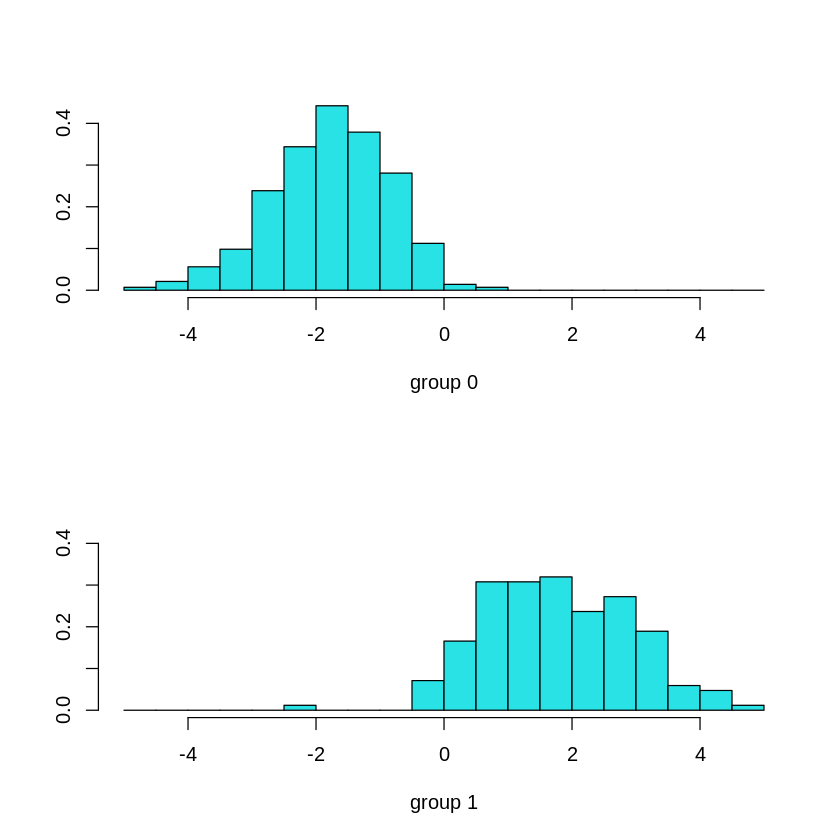

[1] ""
[1] "Dim 3 , Fold 5"
Call:
lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + 
    compactness + concavity + concave_points + symmetry + fractal_dimension, 
    data = trainData)

Prior probabilities of groups:
       0        1 
0.621978 0.378022 

Group means:
    radius  texture perimeter      area smoothness compactness concavity
0 13.38655 23.50254  87.02951  559.9258  0.1241559   0.1831886 0.1709399
1 21.18616 29.28174 141.69983 1426.8628  0.1443697   0.3763402 0.4466621
  concave_points  symmetry fractal_dimension
0     0.07450551 0.2693194        0.07937827
1     0.18256017 0.3216721        0.09150203

Coefficients of linear discriminants:
                           LD1
radius             0.516577353
texture            0.058673963
perimeter          0.007626326
area              -0.002694230
smoothness        10.037060037
compactness       -3.076857855
concavity          0.757905949
concave_points     7.867249519
symmetry           2.384675470
fractal_dim

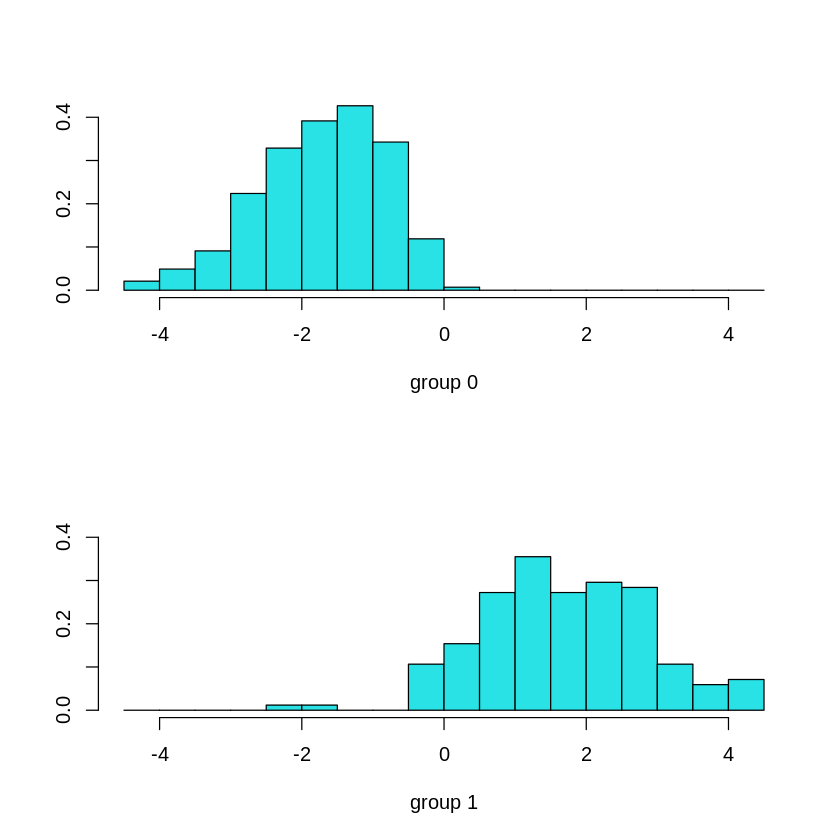

[1] ""


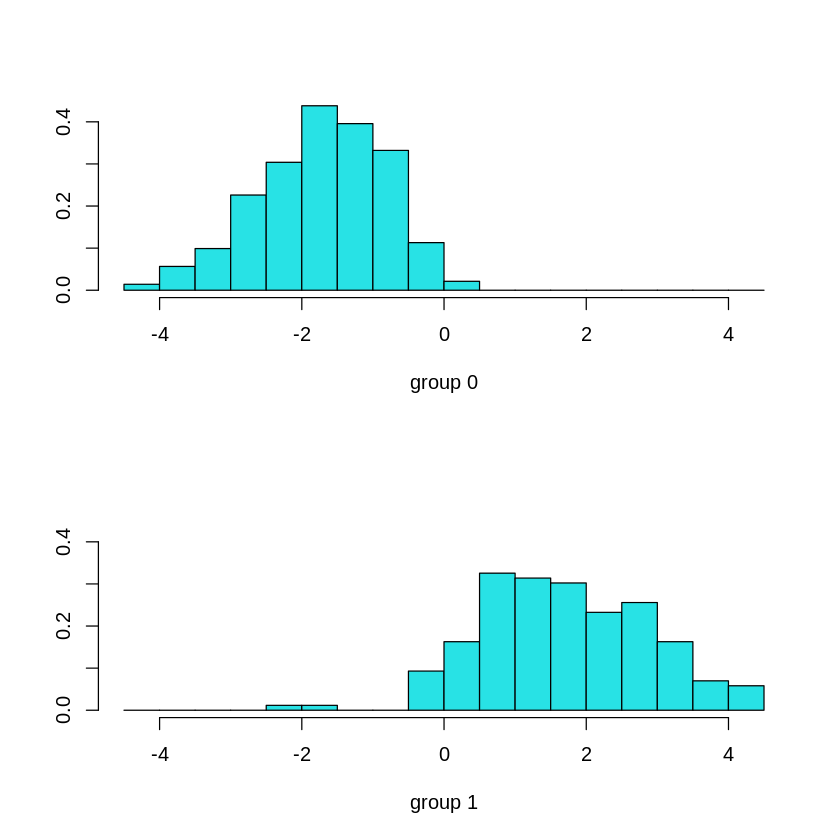

In [ ]:
library(MASS)

dataframe_list <- list("Dim 1" = wdbc_data1, "Dim 2" = wdbc_data2, "Dim 3" = wdbc_data3)

for (df_name in names(dataframe_list)) {
  current_df <- dataframe_list[[df_name]]

  for (cur_group in 1:5) {
  trainData <- current_df %>%
    filter(data_group != cur_group)
  testData <- current_df %>%
    filter(data_group == cur_group)

  lda.fit <- lda(Diagnosis ~ radius + texture + perimeter + area + smoothness + compactness + concavity + concave_points + symmetry + fractal_dimension,
    data = trainData)
  print(paste(df_name, ", Fold",cur_group))
  print(lda.fit)
  plot(lda.fit)
  print("")

  }
}

In [ ]:
#(3) Implement and assess a Classification model:
# A) Select a dataset and classification TARGET and
#select the relevant features you wish to use.
#[You may use data from ISLR or MASS -- or one of the sets we've worked with so far].
#You can either choose a binary classification (where applicable) or
#a multi-class target using the LDA method.
#You may use either a single factor classification (only one feature) or
#multiple features (I suggest you limit your selection to 5).
#-- No performance metrics are required in this case,
#we will assess feature selection in a later assignment.
#Select the division scale (test set size) and
#perform a fit for your model on the training data.
#B ) Repeat the process from the previous step using the k-fold methods:
#
#	Recall selection of k-fold number is important,
#you may select any valid value for the range we've discussed.

In [ ]:
library(class)

#Import WDBC Data
#(1) Use the dataset provided above
source_file_url = "https://raw.githubusercontent.com/joelvinas/COMP-SCI_5565/refs/heads/main/Assignment%203/Data/wdbc.data"

wdbc_data <- read.csv(source_file_url)
all_headers <- c("ID", "Diagnosis",
                 "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1",
                 "radius2", "texture2", "perimeter2", "area2", "smoothness2", "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2",
                 "radius3", "texture3", "perimeter3", "area3", "smoothness3", "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3")

colnames(wdbc_data) <- all_headers
#wdbc_data$Diagnosis[wdbc_data$Diagnosis == "M"] <- 1   #M for Malignant
#wdbc_data$Diagnosis[wdbc_data$Diagnosis == "B"] <- 0  #B for Benign

# Gemini Code suggestion: Robustly convert Diagnosis to numeric 0/1 (0 for 'B', 1 for 'M')
wdbc_data$Diagnosis <- as.numeric(wdbc_data$Diagnosis == "M")

#Break the dataset into 5 parts for later 5-Fold analysis
num_parts <- 5
wdbc_data$data_group <- rep(1:num_parts, length.out = nrow(wdbc_data))

#Split the dataset into the 3 dimensions
wdbc_data1 <- wdbc_data[, c(1,2, 3:12, 33)]
wdbc_data2 <- wdbc_data[, c(1,2, 13:22, 33)]
wdbc_data3 <- wdbc_data[, c(1,2, 23:32, 33)]

# Define new headers for subset
part_headers <- c("ID", "Diagnosis", "radius", "texture", "perimeter", "area", "smoothness", "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension", "data_group")

# Assign the new headers to the new data frames
colnames(wdbc_data1) <- part_headers
colnames(wdbc_data2) <- part_headers
colnames(wdbc_data3) <- part_headers

# This loop was already present in the notebook; leaving it as is for now.
# It prints head and dim information for debugging purposes but doesn't modify dataframes.
dataframe_list <- list("Dim 1" = wdbc_data1, "Dim 2" = wdbc_data2, "Dim 3" = wdbc_data3)

results_df <- data.frame(
  name = character(0),
  accuracy = numeric(0),
  datasource = character(0),
  datagroup = integer(0),
  stringsAsFactors = FALSE
)

for (df_name in names(dataframe_list)) {
  current_df <- dataframe_list[[df_name]]

    # Select up to 5 features
    # Features were selected due to their statistical relation to the model in previous analysis
    # It would have been nice to have this selected programatically, and on a per Dimension basis!
  k_features <- current_df[, c("radius", "texture", "perimeter", "area", "smoothness")]

  # Scale the selected features
  k_scaled_features <- scale(k_features)

  # Extract the Diagnosis column as the target variable
  k_diagnosis <- current_df$Diagnosis

  k_fold_accuracy <- c()
  k_value <- 5 # Define k once

  for (cur_group in 1:5) {
    # Split data into training and testing sets based on DataGroup

    train_indices <- which(current_df$data_group != cur_group)
    test_indices <- which(current_df$data_group == cur_group)

    print(paste(df_name, cur_group))
    #print(head(current_df))

    train_features <- k_scaled_features[train_indices, , drop = FALSE]
    test_features <- k_scaled_features[test_indices, , drop = FALSE]

    print(paste("Number of rows in k_scaled_features:", nrow(k_scaled_features)))
    print(paste("Number of rows in train_features:", nrow(train_features)))
    print(paste("Number of rows in test_features:", nrow(test_features)))

    # Check if training set is empty or has zero rows
    if (nrow(train_features) == 0) {
      cat(paste0("Reason: Training set for Fold ", cur_group, " is empty. This indicates a problem with data splitting or original data availability. Skipping this fold.\n"))
      next
    }

    # Convert diagnosis to factor with explicit levels (0 and 1) to avoid issues with missing levels
    train_diagnosis_factor <- factor(k_diagnosis[train_indices], levels = c(0, 1))
    test_diagnosis_factor <- factor(k_diagnosis[test_indices], levels = c(0, 1))

    cat(paste0("\n--- Fold ", cur_group, " Training Class Distribution ---\n"))
    diagnosis_counts <- table(train_diagnosis_factor)
    print(diagnosis_counts)

    # Check if all classes are present in the training set
    if (length(diagnosis_counts) < 2) {
        cat(paste0("Reason: Training set for Fold ", cur_group, " does not contain both classes (0 and 1). Skipping this fold.\n"))
        next
    }

    # Check if all classes have at least k_value samples in the training set
    if (any(diagnosis_counts < k_value)) {
      cat(paste0("Reason: Insufficient training samples for one or more classes to run KNN with k=", k_value, ". Skipping this fold.\n"))
      next # Skip this fold if conditions are not met
    }

    # Train KNN model using the k-value (k=5)
    knn_pred <- knn(
      train = train_features,
      test = test_features,
      cl = train_diagnosis_factor, # Use the factor version of training labels
      k = k_value
    )

    # Ensure predictions are also factors with correct levels for confusion matrix
    knn_pred_factor <- factor(knn_pred, levels = c(0, 1))

    # Print Confusion Matrix for current fold
    cat(paste0("\n--- Fold ", cur_group, " Results ---\n"))
    confusion_matrix <- table(knn_pred_factor, test_diagnosis_factor)
    print(confusion_matrix)

    # Calculate and print Accuracy for current fold
    accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)
    cat(paste0("Accuracy: ", round(accuracy, 4), "\n"))
    k_fold_accuracy <- c(k_fold_accuracy, accuracy)
  }

  if (length(k_fold_accuracy) > 0) {
      cat("\nAverage K-Fold Accuracy for ", df_name, ": ", mean(k_fold_accuracy), "\n")
  } else {
      cat("\nNo folds were processed successfully for ", df_name, " due to insufficient training data for KNN.\n")
  }

  # Add new row to results
  new_results <- data.frame(
    name = paste(df_name,cur_group),
    accuracy = k_fold_accuracy,
    datasource = df_name,
    datagroup = cur_group,
    stringsAsFactors = FALSE
  )

  # Add the new row
  results_df <- rbind(results_df, new_results)

}

[1] "Dim 1 1"
[1] "Number of rows in k_scaled_features: 568"
[1] "Number of rows in train_features: 454"
[1] "Number of rows in test_features: 114"

--- Fold 1 Training Class Distribution ---
train_diagnosis_factor
  0   1 
281 173 

--- Fold 1 Results ---
               test_diagnosis_factor
knn_pred_factor  0  1
              0 73  7
              1  3 31
Accuracy: 0.9123
[1] "Dim 1 2"
[1] "Number of rows in k_scaled_features: 568"
[1] "Number of rows in train_features: 454"
[1] "Number of rows in test_features: 114"

--- Fold 2 Training Class Distribution ---
train_diagnosis_factor
  0   1 
293 161 

--- Fold 2 Results ---
               test_diagnosis_factor
knn_pred_factor  0  1
              0 62  6
              1  2 44
Accuracy: 0.9298
[1] "Dim 1 3"
[1] "Number of rows in k_scaled_features: 568"
[1] "Number of rows in train_features: 454"
[1] "Number of rows in test_features: 114"

--- Fold 3 Training Class Distribution ---
train_diagnosis_factor
  0   1 
285 169 

--- Fold 3 R

In [ ]:
library(dplyr)

dataframe_list <- list("Dim 1" = wdbc_data1, "Dim 2" = wdbc_data2, "Dim 3" = wdbc_data3)

for (df_name in names(dataframe_list)) {

mean_accuracy <- results_df %>%
  filter(datasource == df_name) %>%
  summarize(mean_acc = mean(accuracy))

print(paste("Mean Accuracy for ",df_name,":", mean_accuracy$mean_acc))

}

[1] "Mean Accuracy for  Dim 1 : 0.915463437354448"
[1] "Mean Accuracy for  Dim 2 : 0.836143455985095"
[1] "Mean Accuracy for  Dim 3 : 0.971852196863841"
